### UMAP algoritmo pavyzdžiai

In [1]:
import umap
import pandas as pd
import matplotlib.pyplot as plt

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ellipsoid = pd.read_csv('./ellipsoid.50d10c.8.txt', sep='\t', header=None)

In [3]:
iris = pd.read_csv('./iris_with_class.txt', sep='\t', header=None)

In [4]:
iris[4] = iris[4].map({'Iris-setosa':1,
                       'Iris-versicolor':2,
                       'Iris-virginica':3})

In [5]:
mnist = pd.read_csv('./mnist_train.csv')
print(mnist.columns.tolist())
X = mnist.iloc[:, 1:].values   # features
y = mnist.iloc[:, 0].values    # labels
print(X.shape)

['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10', '1x11', '1x12', '1x13', '1x14', '1x15', '1x16', '1x17', '1x18', '1x19', '1x20', '1x21', '1x22', '1x23', '1x24', '1x25', '1x26', '1x27', '1x28', '2x1', '2x2', '2x3', '2x4', '2x5', '2x6', '2x7', '2x8', '2x9', '2x10', '2x11', '2x12', '2x13', '2x14', '2x15', '2x16', '2x17', '2x18', '2x19', '2x20', '2x21', '2x22', '2x23', '2x24', '2x25', '2x26', '2x27', '2x28', '3x1', '3x2', '3x3', '3x4', '3x5', '3x6', '3x7', '3x8', '3x9', '3x10', '3x11', '3x12', '3x13', '3x14', '3x15', '3x16', '3x17', '3x18', '3x19', '3x20', '3x21', '3x22', '3x23', '3x24', '3x25', '3x26', '3x27', '3x28', '4x1', '4x2', '4x3', '4x4', '4x5', '4x6', '4x7', '4x8', '4x9', '4x10', '4x11', '4x12', '4x13', '4x14', '4x15', '4x16', '4x17', '4x18', '4x19', '4x20', '4x21', '4x22', '4x23', '4x24', '4x25', '4x26', '4x27', '4x28', '5x1', '5x2', '5x3', '5x4', '5x5', '5x6', '5x7', '5x8', '5x9', '5x10', '5x11', '5x12', '5x13', '5x14', '5x15', '5x16', '5x17', '5x

In [6]:
swiss = pd.read_csv("swiss_roll_example.csv", sep=";", header=None)
print(swiss.shape)

(400, 3)


### UMAP hiperparametrų keitimas

In [7]:
def plot_iris(data, n_neighbors=15, min_dist=0.1, metric='euclidean', ax=None, var='n_neighbors'):
    data_umap = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=1).fit_transform(iris[[0, 1, 2, 3]])
    
    if ax is None:
        ax = plt.gca()

    ax.scatter(data_umap[:, 0], data_umap[:, 1], s=15, alpha=0.8, c=iris[4])

    ax.set_title(f"{var}={locals()[var]}")

In [7]:
def plot_ellipsoid(data, n_neighbors=15, min_dist=0.1, metric='euclidean', ax=None, var='n_neighbors'):
    data_umap = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=1).fit_transform(data)
    
    if ax is None:
        ax = plt.gca()


    ax.scatter(data_umap[:, 0], data_umap[:, 1], s=15, alpha=0.8)

    ax.set_title(f"{var}={locals()[var]}")

#### Kintamojo `n_neighbors` įtaka

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

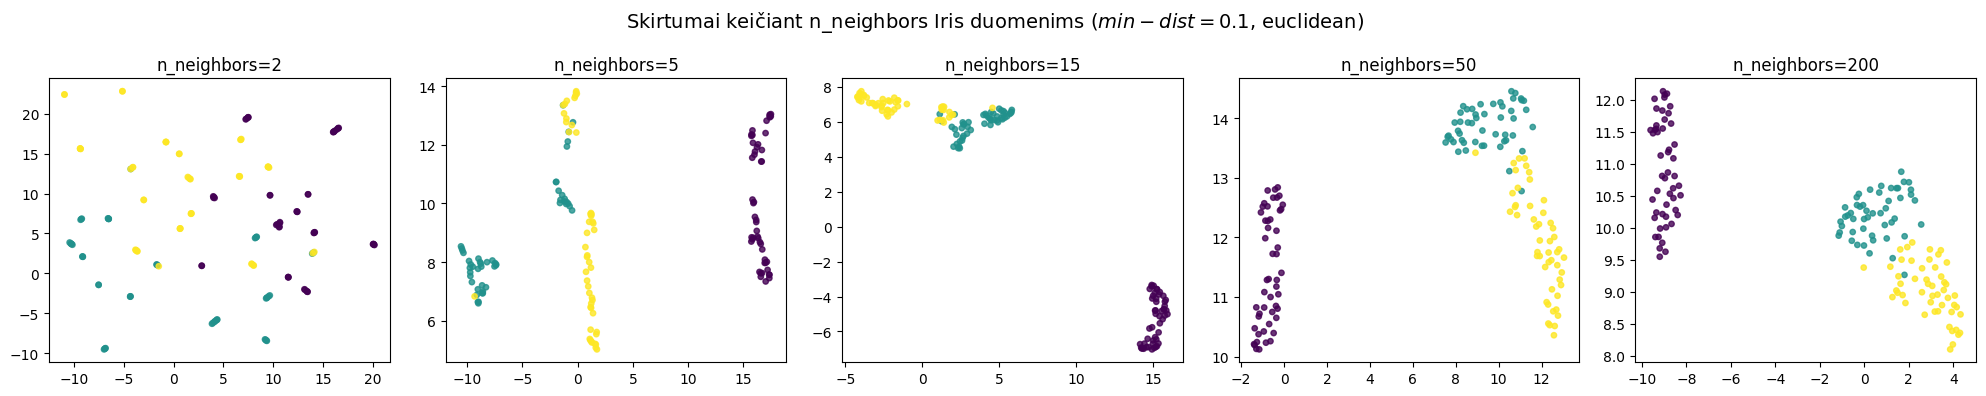

In [9]:
neighbors_values = [2, 5, 15, 50, 200]
fig, axs = plt.subplots(1, len(neighbors_values), figsize=(20, 4))
fig.suptitle('Skirtumai keičiant n_neighbors Iris duomenims ($min-dist=0.1$, euclidean)', fontsize=14)

for i, n in enumerate(neighbors_values):
    plot_iris(iris[[0, 1, 2, 3]], n_neighbors=n, ax=axs[i])

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

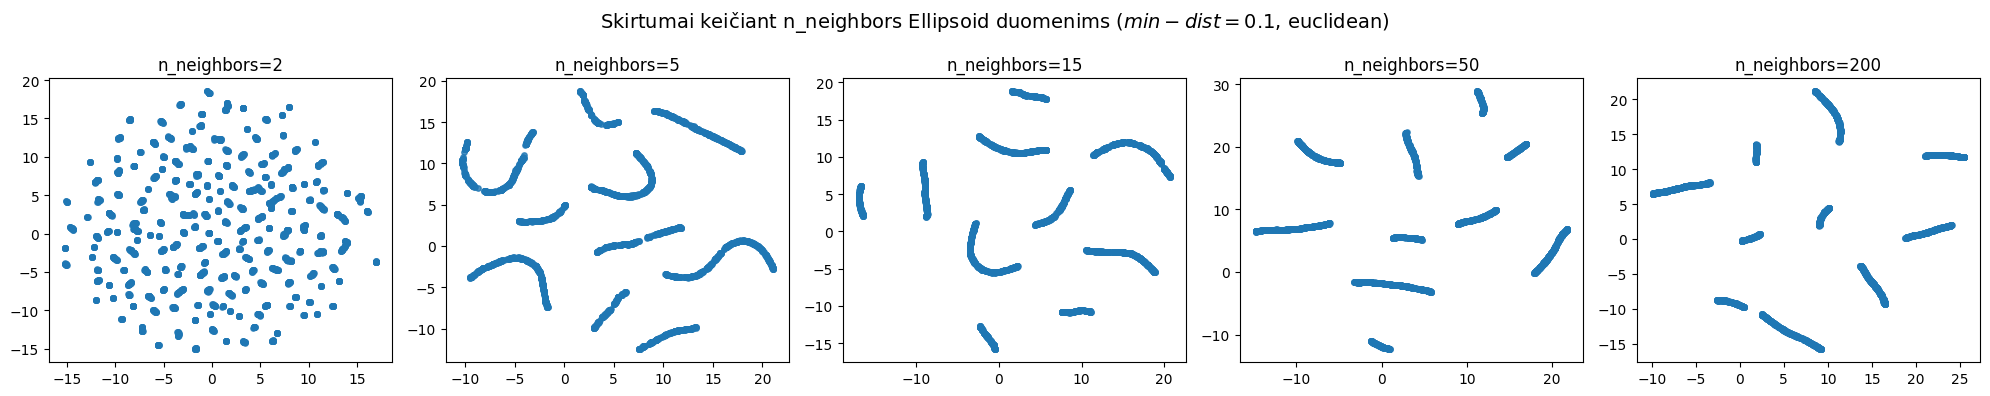

In [10]:
neighbors_values = [2, 5, 15, 50, 200]
fig, axs = plt.subplots(1, len(neighbors_values), figsize=(20, 4))
fig.suptitle('Skirtumai keičiant n_neighbors Ellipsoid duomenims ($min-dist=0.1$, euclidean)', fontsize=14)

for i, n in enumerate(neighbors_values):
    plot_ellipsoid(ellipsoid, n_neighbors=n, ax=axs[i])

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/v

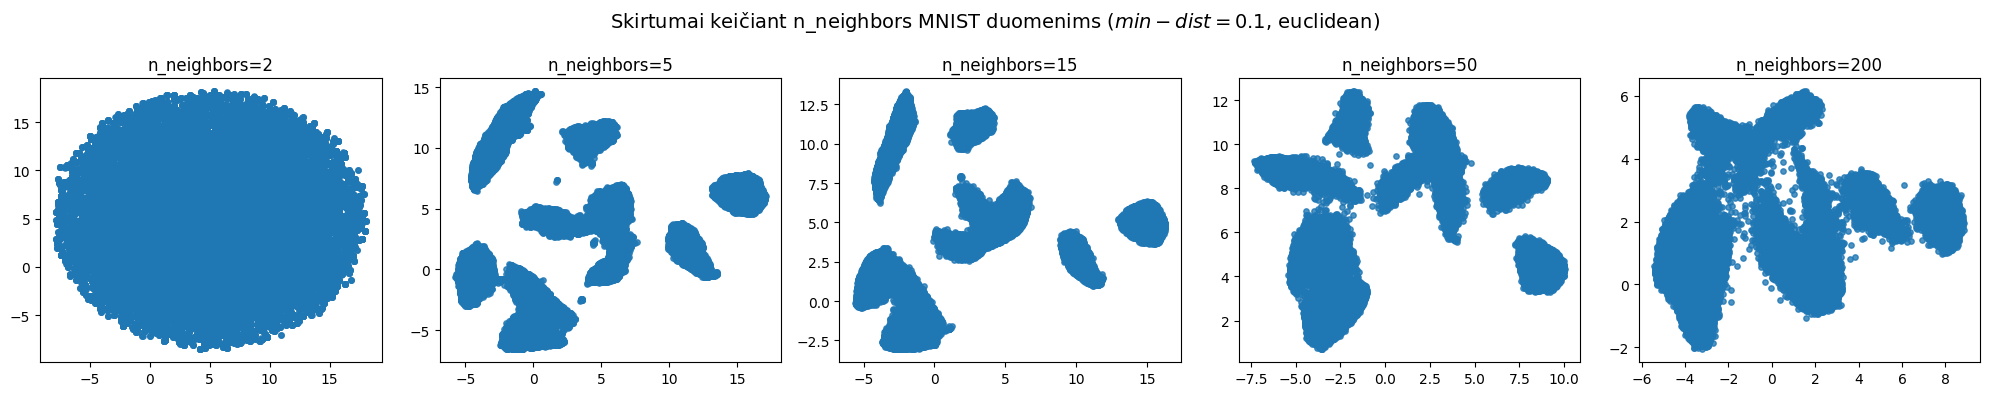

In [ ]:
neighbors_values = [2, 5, 15, 50, 200]
fig, axs = plt.subplots(1, len(neighbors_values), figsize=(20, 4))
fig.suptitle('Skirtumai keičiant n_neighbors MNIST duomenims ($min-dist=0.1$, euclidean)', fontsize=14)

for i, n in enumerate(neighbors_values):
    plot_ellipsoid(mnist, n_neighbors=n, ax=axs[i])

# ax.scatter(mnist[:, 0],
#            mnist[:, 1],
#            c=y,
#            cmap='tab10',
#            s=10)
plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:449: UserWarning: Exited at iteration 2000 with accuracies 
[5.51953556e-15 1.27734480e-06 2.24654632e-06 2.75612315e-05]
not reaching the requested tolerance 1.8775463104248047e-06.
Use iteration 1758 instead with accuracy 
4.396112579732875e-06.

  _, diffusion_map = lobpcg(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:449: UserWarning: Exited postprocessing with accuracies 
[2.57144314e-15 4.64944179e-07 8.24860983e-07 1.62946638e-05]
not reaching the requested tolerance 1.8775463104248047e-06.
  _, diffusion_map = lobpcg(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/pyth

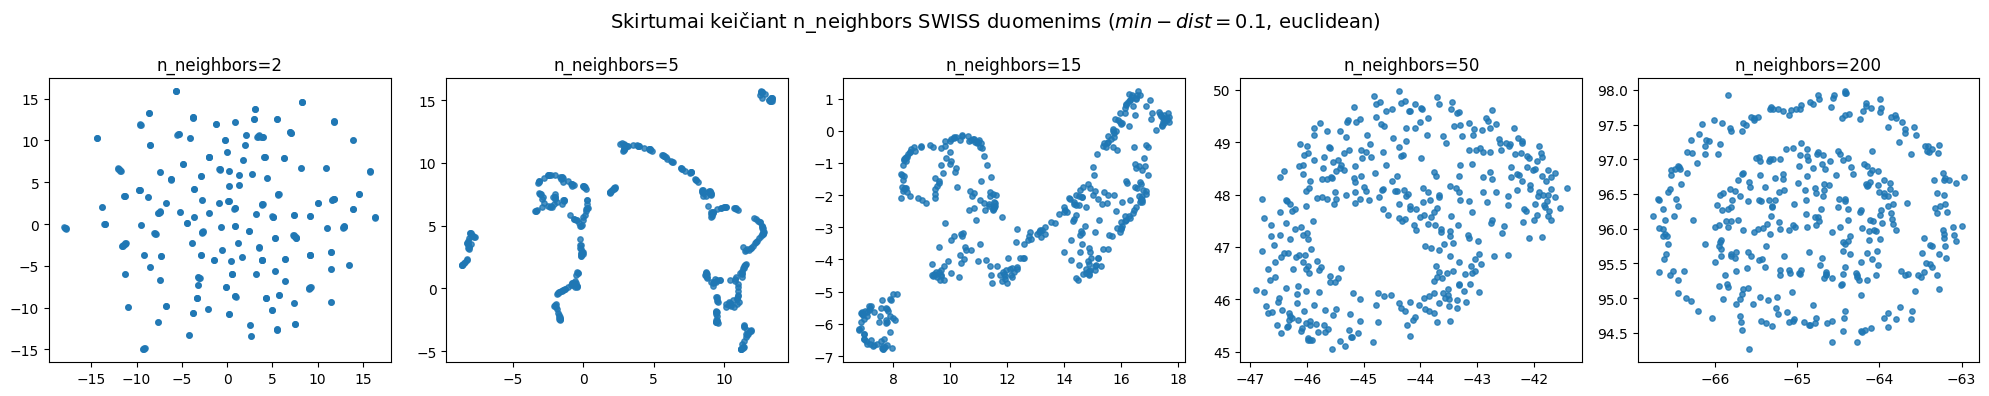

In [8]:
neighbors_values = [2, 5, 15, 50, 200]
fig, axs = plt.subplots(1, len(neighbors_values), figsize=(20, 4))
fig.suptitle('Skirtumai keičiant n_neighbors SWISS duomenims ($min-dist=0.1$, euclidean)', fontsize=14)

for i, n in enumerate(neighbors_values):
    plot_ellipsoid(swiss, n_neighbors=n, ax=axs[i])

plt.tight_layout()
plt.show()

#### Kintamojo `min_dist` įtaka

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

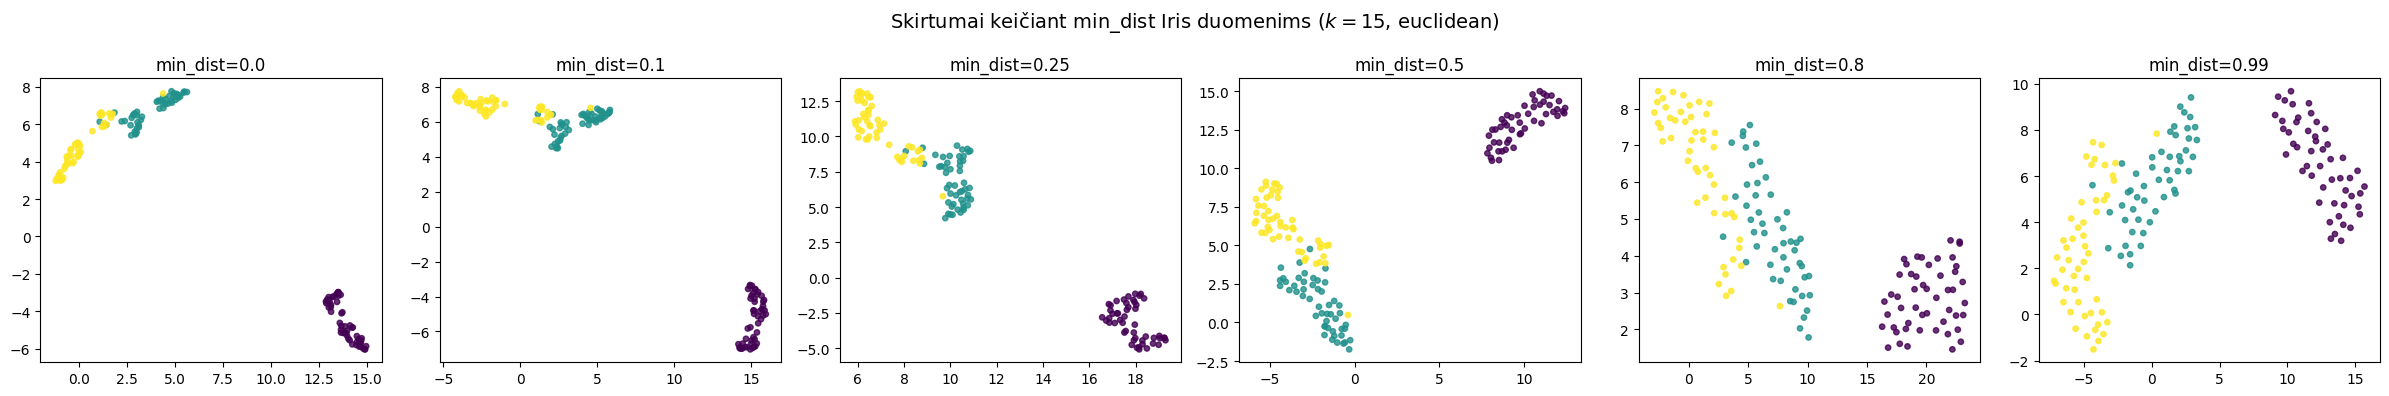

In [11]:
dist_values = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]
fig, axs = plt.subplots(1, len(dist_values), figsize=(24, 4))

fig.suptitle('Skirtumai keičiant min_dist Iris duomenims ($k=15$, euclidean)', fontsize=14)

for i, d in enumerate(dist_values):
    plot_iris(iris[[0, 1, 2, 3]], min_dist=d, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

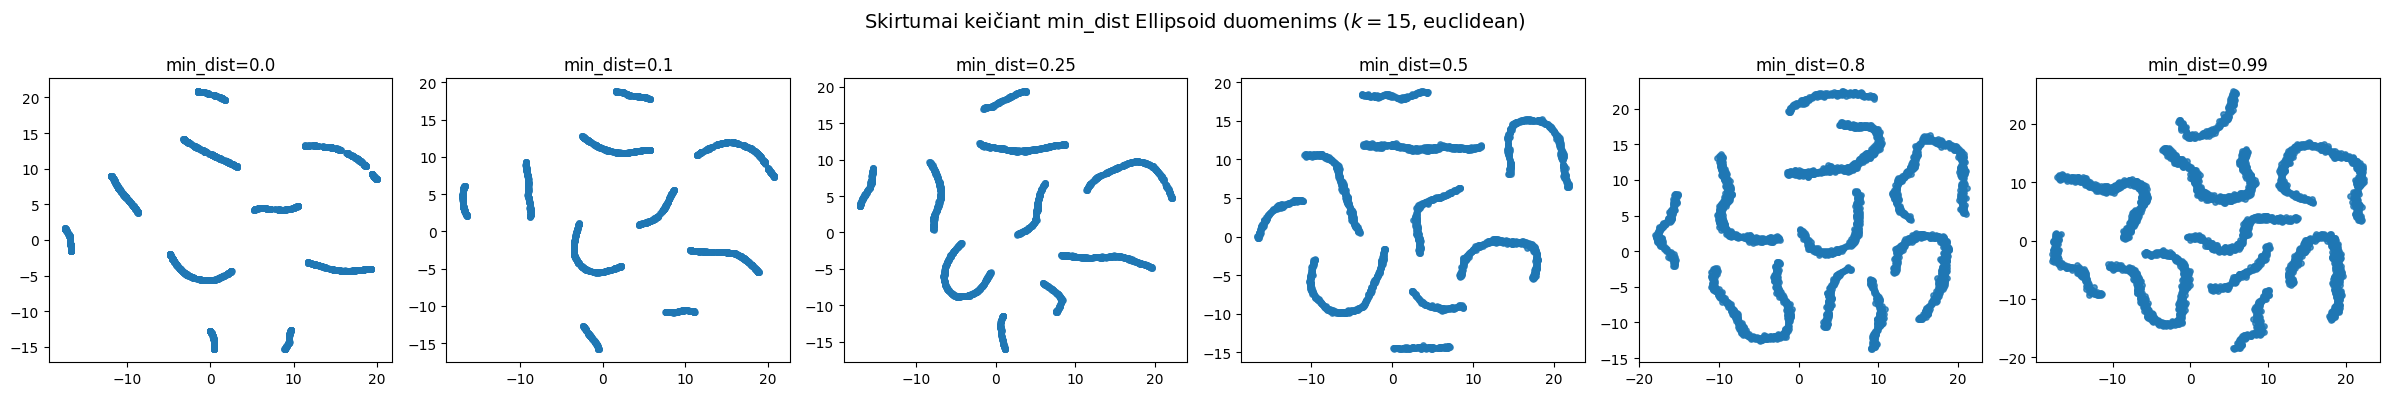

In [12]:
dist_values = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]
fig, axs = plt.subplots(1, len(dist_values), figsize=(24, 4))
fig.suptitle('Skirtumai keičiant min_dist Ellipsoid duomenims ($k=15$, euclidean)', fontsize=14)

for i, d in enumerate(dist_values):
    plot_ellipsoid(ellipsoid, min_dist=d, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

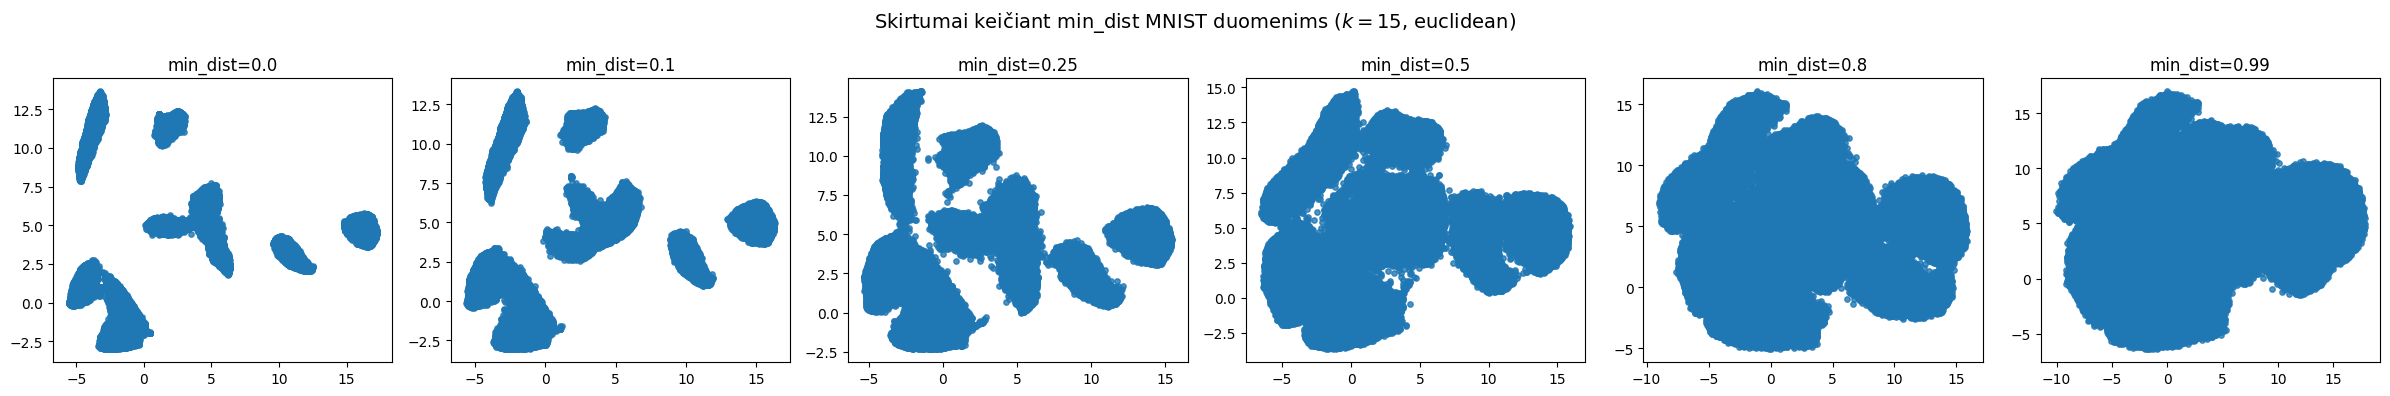

In [ ]:
dist_values = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]
fig, axs = plt.subplots(1, len(dist_values), figsize=(24, 4))
fig.suptitle('Skirtumai keičiant min_dist MNIST duomenims ($k=15$, euclidean)', fontsize=14)

for i, d in enumerate(dist_values):
    plot_ellipsoid(swiss, min_dist=d, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

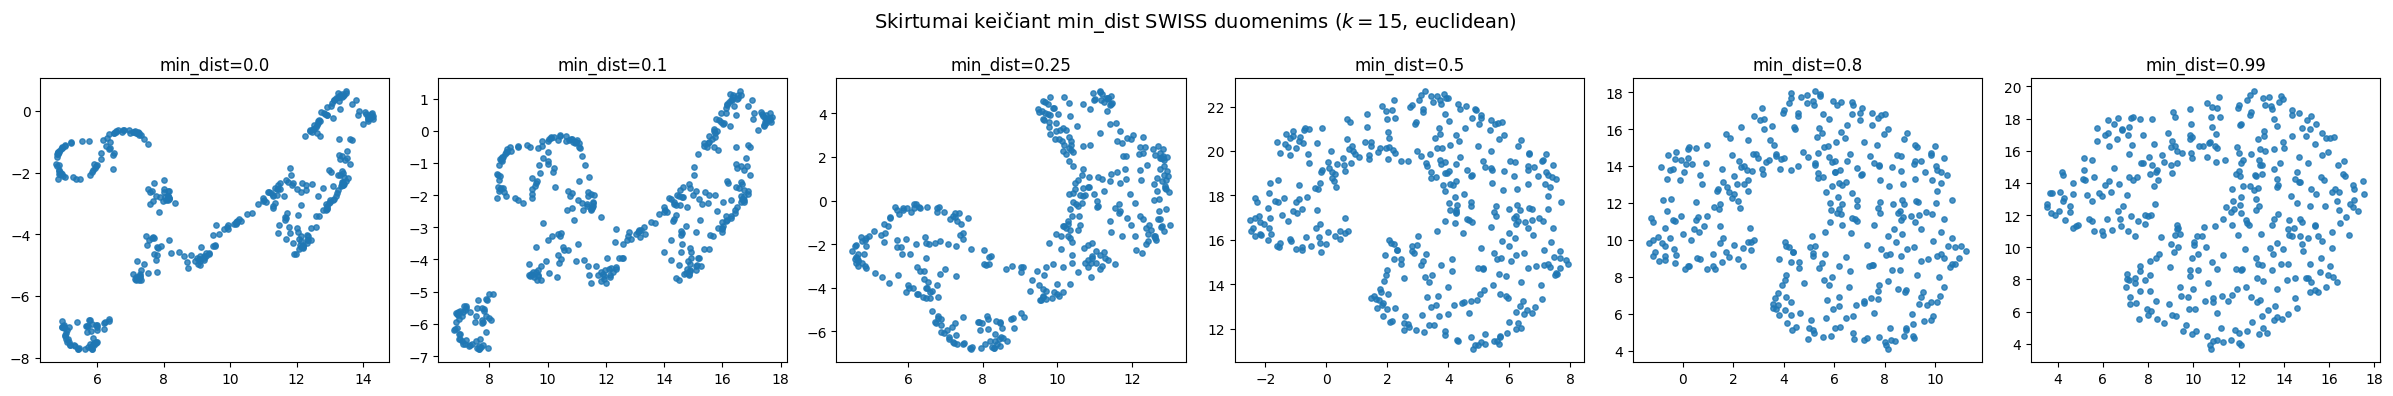

In [9]:
dist_values = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]
fig, axs = plt.subplots(1, len(dist_values), figsize=(24, 4))
fig.suptitle('Skirtumai keičiant min_dist SWISS duomenims ($k=15$, euclidean)', fontsize=14)

for i, d in enumerate(dist_values):
    plot_ellipsoid(swiss, min_dist=d, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.show()

#### Kintamojo `metric` įtaka

In [11]:
metrics = ['euclidean', 'manhattan', 'chebyshev', 'cosine']

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


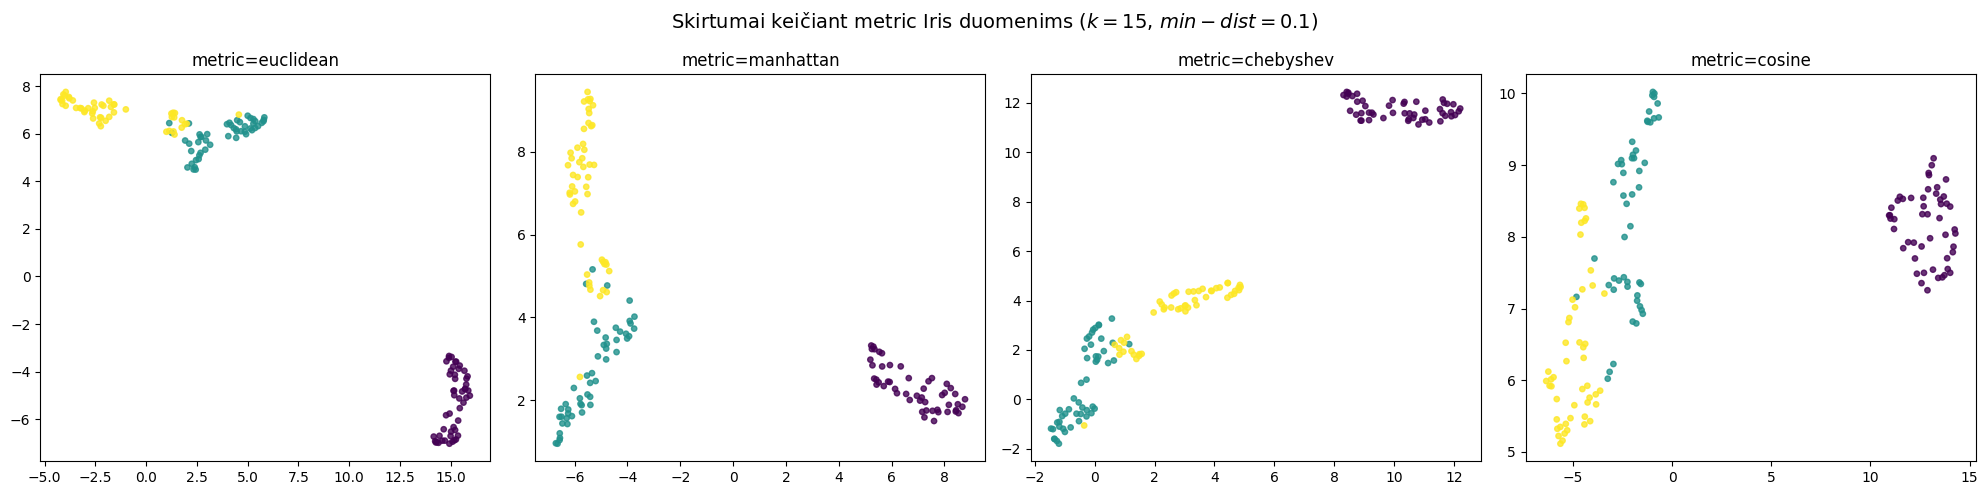

In [ ]:
fig, axs = plt.subplots(1, len(metrics), figsize=(20, 5))


fig.suptitle('Skirtumai keičiant metric Iris duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, m in enumerate(metrics):
    plot_iris(iris[[0, 1, 2, 3]], metric=m, ax=axs[i], var='metric')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


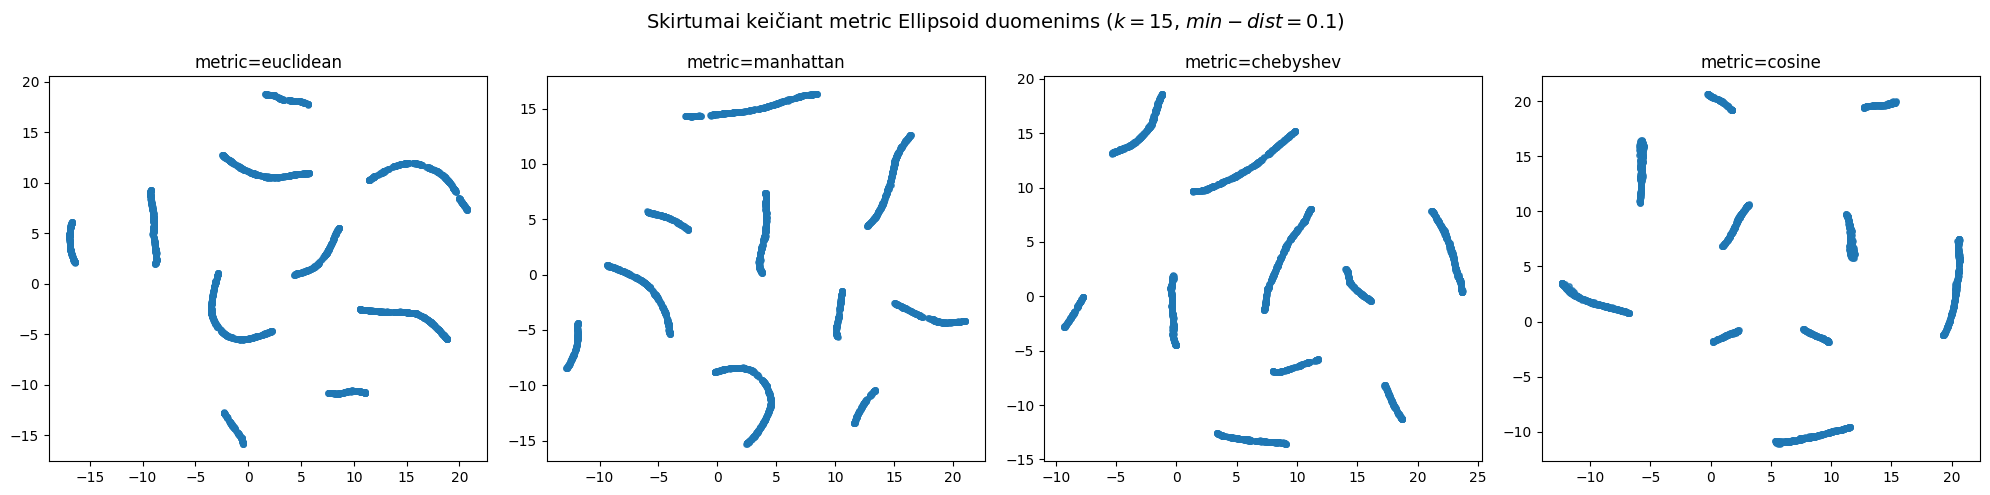

In [14]:
fig, axs = plt.subplots(1, len(metrics), figsize=(20, 5))
fig.suptitle('Skirtumai keičiant metric Ellipsoid duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, m in enumerate(metrics):
    plot_ellipsoid(ellipsoid, metric=m, ax=axs[i], var='metric')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


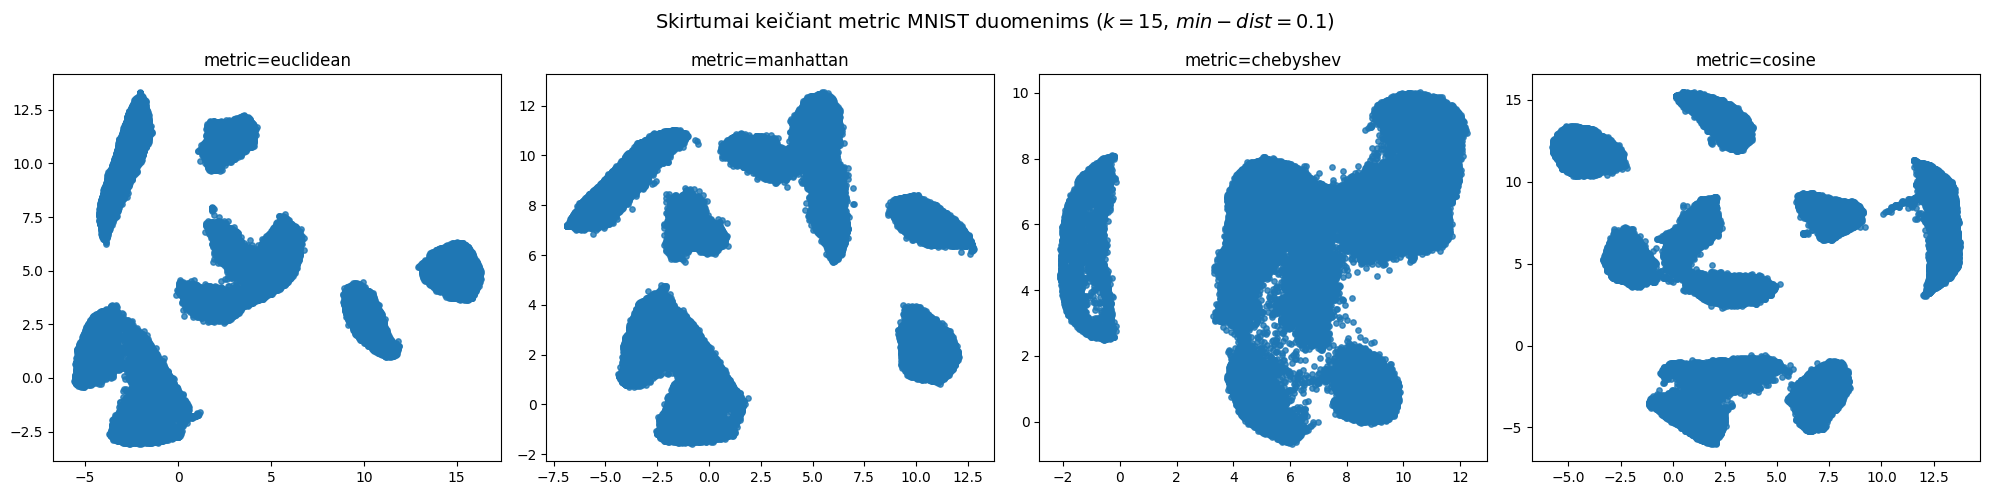

In [20]:
fig, axs = plt.subplots(1, len(metrics), figsize=(20, 5))
fig.suptitle('Skirtumai keičiant metric MNIST duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, m in enumerate(metrics):
    plot_ellipsoid(mnist, metric=m, ax=axs[i], var='metric')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


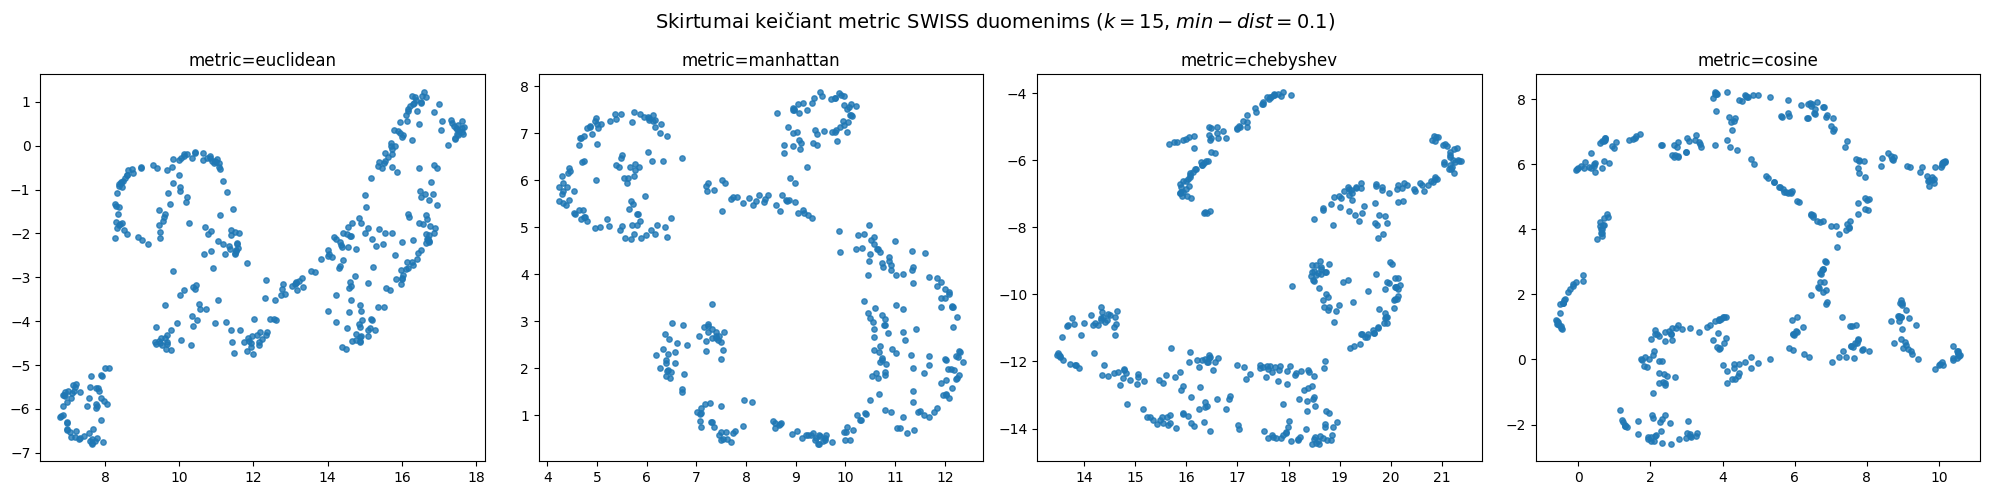

In [12]:
fig, axs = plt.subplots(1, len(metrics), figsize=(20, 5))
fig.suptitle('Skirtumai keičiant metric SWISS duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, m in enumerate(metrics):
    plot_ellipsoid(swiss, metric=m, ax=axs[i], var='metric')

plt.tight_layout()
plt.show()